## Phase 13: Interactive Visualization & Dashboard Preparation

This phase prepares the analytical results from the previous stages for
interactive visualization and dashboard development.

The objective is to create concise, presentation-ready datasets and
visualizations covering:

- Overall movie statistics
- Genre popularity
- Genre evolution over time
- Rating trends
- Audience engagement
- Genre combinations
- Machine learning cluster insights

The prepared outputs will serve as the foundation for the final
interactive dashboard.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/processed/movies_feature_engineered.csv"
)

print("Dataset loaded successfully.")
print("Dataset Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Dataset Shape: (569655, 46)


,tconst,titleType,primaryTitle,startYear,runtimeMinutes,genres,genre_list,averageRating,numVotes,year,...,genre_sport,genre_talk_show,genre_thriller,genre_war,genre_western,runtime_category,rating_category,log_votes,popularity_category,rating_popularity_score
0,tt0000574,movie,The Story of the Kelly Gang,1906,70.0,"Action,Adventure,Biography","['Action', 'Adventure', 'Biography']",6.0,1084.0,1906,...,0,0,0,0,0,Short,Average,6.989335,Popular,41.936012
1,tt0000591,movie,The Prodigal Son,1907,90.0,Drama,['Drama'],4.8,40.0,1907,...,0,0,0,0,0,Medium,Low,3.713572,Low,17.825146
2,tt0000615,movie,Robbery Under Arms,1907,NaN,Drama,['Drama'],3.4,36.0,1907,...,0,0,0,0,0,Unknown,Low,3.610918,Low,12.277121
3,tt0000630,movie,Hamlet,1908,NaN,Drama,['Drama'],3.0,42.0,1908,...,0,0,0,0,0,Unknown,Low,3.761200,Low,11.283600
4,tt0000675,movie,Don Quijote,1908,NaN,Drama,['Drama'],3.8,32.0,1908,...,0,0,0,0,0,Unknown,Low,3.496508,Low,13.286729


In [22]:
# Create overall dashboard KPIs
dashboard_kpis = pd.DataFrame({
    "metric": [
        "Total Movies",
        "Average Rating",
        "Total Votes",
        "Average Runtime",
        "Earliest Movie Year",
        "Latest Movie Year"
    ],
    
    "value": [
        len(df),
        round(df["averageRating"].mean(), 2),
        int(df["numVotes"].sum()),
        round(df["runtimeMinutes"].mean(), 2),
        int(df["year"].min()),
        int(df["year"].max())
    ]
})

display(dashboard_kpis)

,metric,value
0,Total Movies,5.696550e+05
1,Average Rating,6.130000e+00
2,Total Votes,1.290659e+09
3,Average Runtime,8.954000e+01
4,Earliest Movie Year,1.900000e+03
5,Latest Movie Year,2.026000e+03


In [23]:
# Prepare individual genre statistics for dashboard

genre_dashboard = (
    df[
        ["genres", "averageRating", "numVotes"]
    ]
    .dropna(subset=["genres"])
    .copy()
)

genre_dashboard["genre"] = (
    genre_dashboard["genres"]
    .str.split(",")
)

genre_dashboard = genre_dashboard.explode("genre")

genre_dashboard["genre"] = (
    genre_dashboard["genre"]
    .str.strip()
)

genre_dashboard_summary = (
    genre_dashboard
    .groupby("genre")
    .agg(
        movie_count=("genre", "size"),
        avg_rating=("averageRating", "mean"),
        avg_votes=("numVotes", "mean")
    )
    .reset_index()
)

genre_dashboard_summary[
    ["avg_rating", "avg_votes"]
] = genre_dashboard_summary[
    ["avg_rating", "avg_votes"]
].round(2)

genre_dashboard_summary = (
    genre_dashboard_summary
    .sort_values("movie_count", ascending=False)
)

display(genre_dashboard_summary.head(20))

,genre,movie_count,avg_rating,avg_votes
8,Drama,240101,6.18,4128.65
7,Documentary,139858,7.17,318.80
5,Comedy,109361,5.88,4651.08
0,Action,49704,5.72,10946.57
20,Romance,49304,6.06,4164.47
6,Crime,38141,5.96,8328.28
24,Thriller,37977,5.57,7513.61
14,Horror,34077,4.96,5110.09
2,Adventure,26762,5.84,16111.44
9,Family,17923,6.14,4252.31


In [24]:
# Prepare decade-level statistics

decade_dashboard = (
    df[
        ["year", "averageRating", "numVotes"]
    ]
    .dropna()
    .copy()
)

decade_dashboard["decade"] = (
    np.floor(decade_dashboard["year"] / 10) * 10
).astype(int)

decade_dashboard_summary = (
    decade_dashboard
    .groupby("decade")
    .agg(
        movie_count=("year", "size"),
        avg_rating=("averageRating", "mean"),
        avg_votes=("numVotes", "mean")
    )
    .reset_index()
)

decade_dashboard_summary[
    ["avg_rating", "avg_votes"]
] = decade_dashboard_summary[
    ["avg_rating", "avg_votes"]
].round(2)

display(decade_dashboard_summary)

,decade,movie_count,avg_rating,avg_votes
0,1900,106,3.27,46.92
1,1910,2012,5.71,143.64
2,1920,3957,5.83,592.69
3,1930,8990,6.01,816.93
4,1940,8888,6.14,1294.94
5,1950,12855,6.15,1465.19
6,1960,17127,6.04,1494.17
7,1970,22732,5.89,1893.81
8,1980,25128,5.95,3203.09
9,1990,26102,6.02,6630.45


In [25]:
# Prepare genre evolution data for dashboard
genre_trend = (
    df[
        ["year", "genres"]
    ]
    .dropna()
    .copy()
)
genre_trend["decade"] = (
    np.floor(genre_trend["year"] / 10) * 10
).astype(int)

genre_trend["genre"] = (
    genre_trend["genres"]
    .str.split(",")
)

genre_trend = genre_trend.explode("genre")

genre_trend["genre"] = (
    genre_trend["genre"]
    .str.strip()
)

genre_trend_summary = (
    genre_trend
    .groupby(["decade", "genre"])
    .size()
    .reset_index(name="movie_count")
)

display(
    genre_trend_summary.head(20)
)

,decade,genre,movie_count
0,1900,Action,2
1,1900,Adventure,3
2,1900,Biography,4
3,1900,Comedy,6
4,1900,Documentary,71
5,1900,Drama,20
6,1900,Family,1
7,1900,Fantasy,2
8,1900,History,3
9,1900,Horror,1


In [26]:
# Save dashboard-ready datasets
dashboard_kpis.to_csv(
    "../data/processed/dashboard_kpis.csv",
    index=False
)

genre_dashboard_summary.to_csv(
    "../data/processed/dashboard_genre_summary.csv",
    index=False
)

decade_dashboard_summary.to_csv(
    "../data/processed/dashboard_decade_summary.csv",
    index=False
)

genre_trend_summary.to_csv(
    "../data/processed/dashboard_genre_trends.csv",
    index=False
)

print("Dashboard datasets saved successfully.")

Dashboard datasets saved successfully.


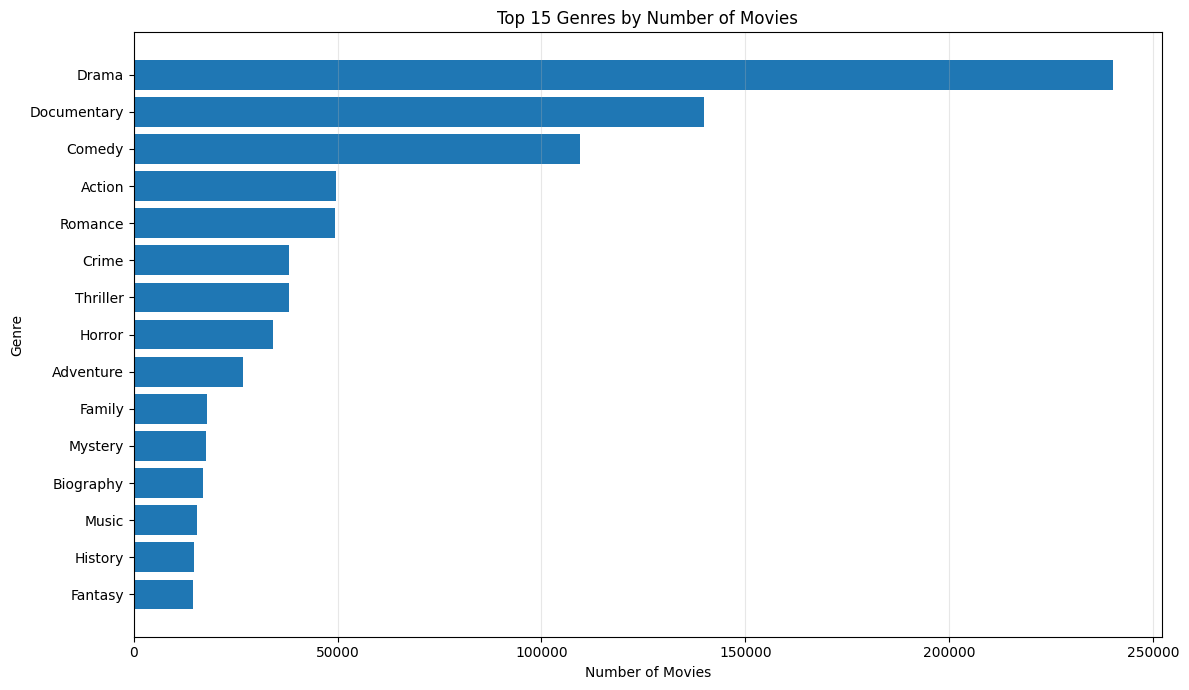

In [27]:
# Top 15 genres by movie count

top_genres = genre_dashboard_summary.head(15)

plt.figure(figsize=(12, 7))

plt.barh(
    top_genres["genre"][::-1],
    top_genres["movie_count"][::-1]
)

plt.title("Top 15 Genres by Number of Movies")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

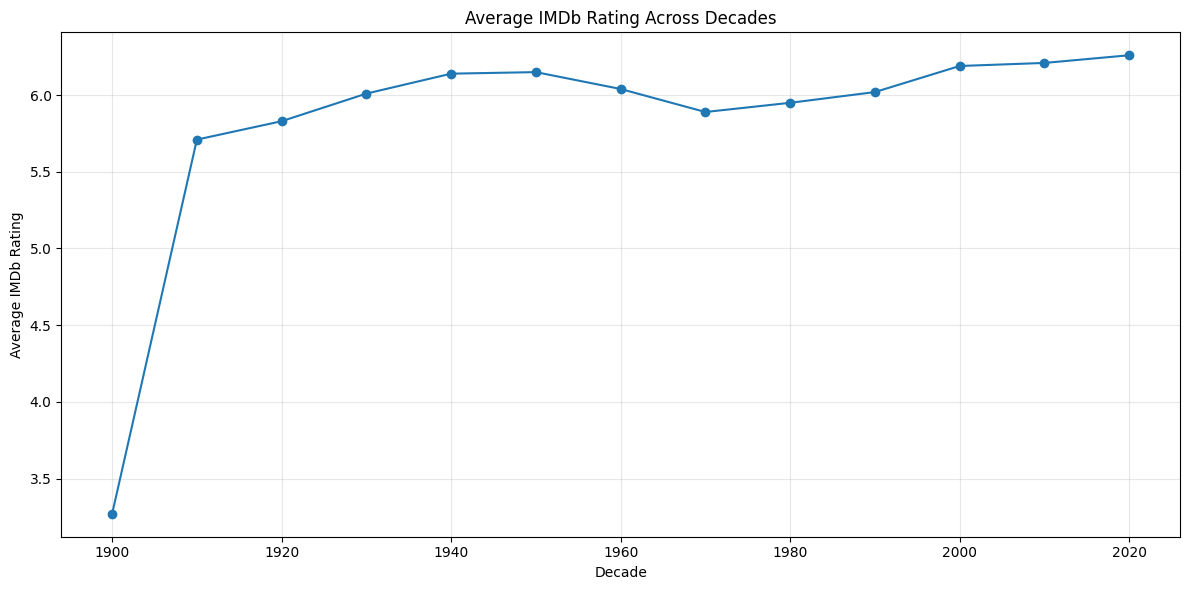

In [28]:
# Average IMDb rating across decades

plt.figure(figsize=(12, 6))

plt.plot(
    decade_dashboard_summary["decade"],
    decade_dashboard_summary["avg_rating"],
    marker="o"
)

plt.title("Average IMDb Rating Across Decades")
plt.xlabel("Decade")
plt.ylabel("Average IMDb Rating")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

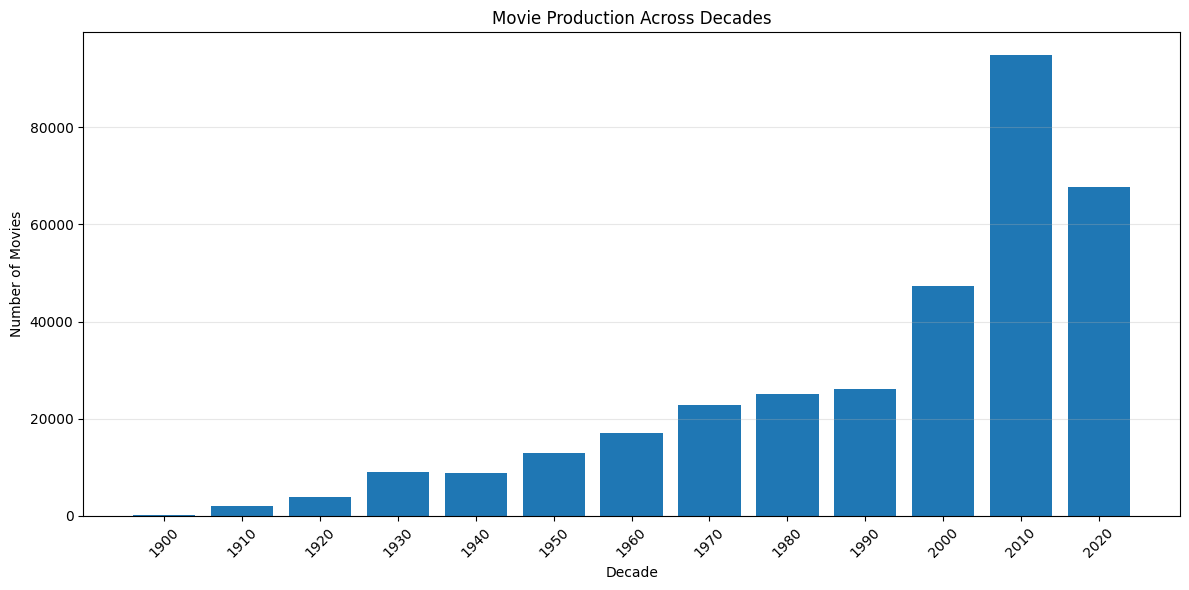

In [29]:
# Movie production across decades

plt.figure(figsize=(12, 6))

plt.bar(
    decade_dashboard_summary["decade"].astype(str),
    decade_dashboard_summary["movie_count"]
)

plt.title("Movie Production Across Decades")
plt.xlabel("Decade")
plt.ylabel("Number of Movies")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

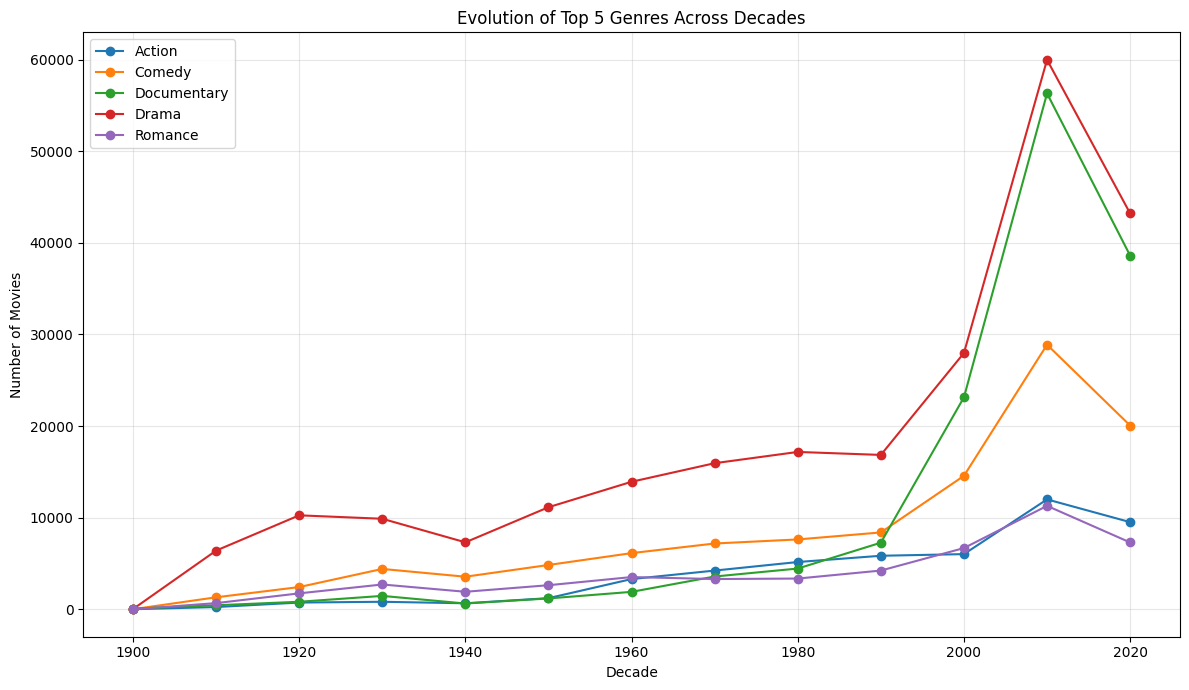

In [30]:
# Top genre evolution across decades

top_genres_list = (
    genre_dashboard_summary
    .head(5)["genre"]
    .tolist()
)

genre_trend_pivot = (
    genre_trend_summary[
        genre_trend_summary["genre"].isin(top_genres_list)
    ]
    .pivot(
        index="decade",
        columns="genre",
        values="movie_count"
    )
    .fillna(0)
)

plt.figure(figsize=(12, 7))

for genre in genre_trend_pivot.columns:
    plt.plot(
        genre_trend_pivot.index,
        genre_trend_pivot[genre],
        marker="o",
        label=genre
    )

plt.title("Evolution of Top 5 Genres Across Decades")
plt.xlabel("Decade")
plt.ylabel("Number of Movies")
plt.legend()

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

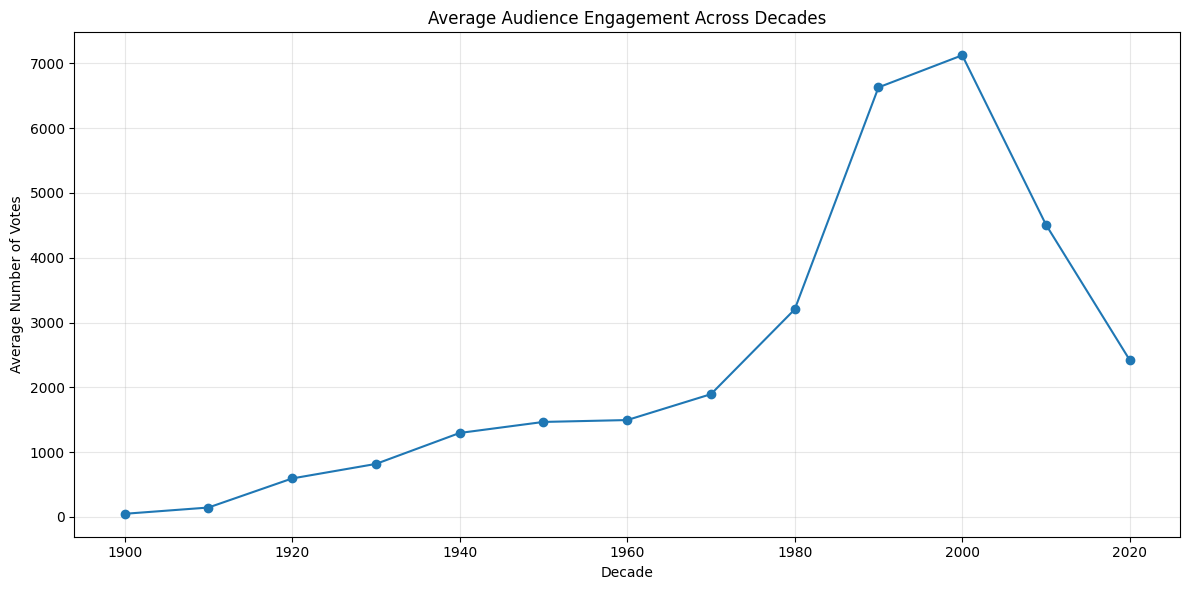

In [31]:
# Average audience engagement across decades

plt.figure(figsize=(12, 6))

plt.plot(
    decade_dashboard_summary["decade"],
    decade_dashboard_summary["avg_votes"],
    marker="o"
)

plt.title("Average Audience Engagement Across Decades")
plt.xlabel("Decade")
plt.ylabel("Average Number of Votes")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

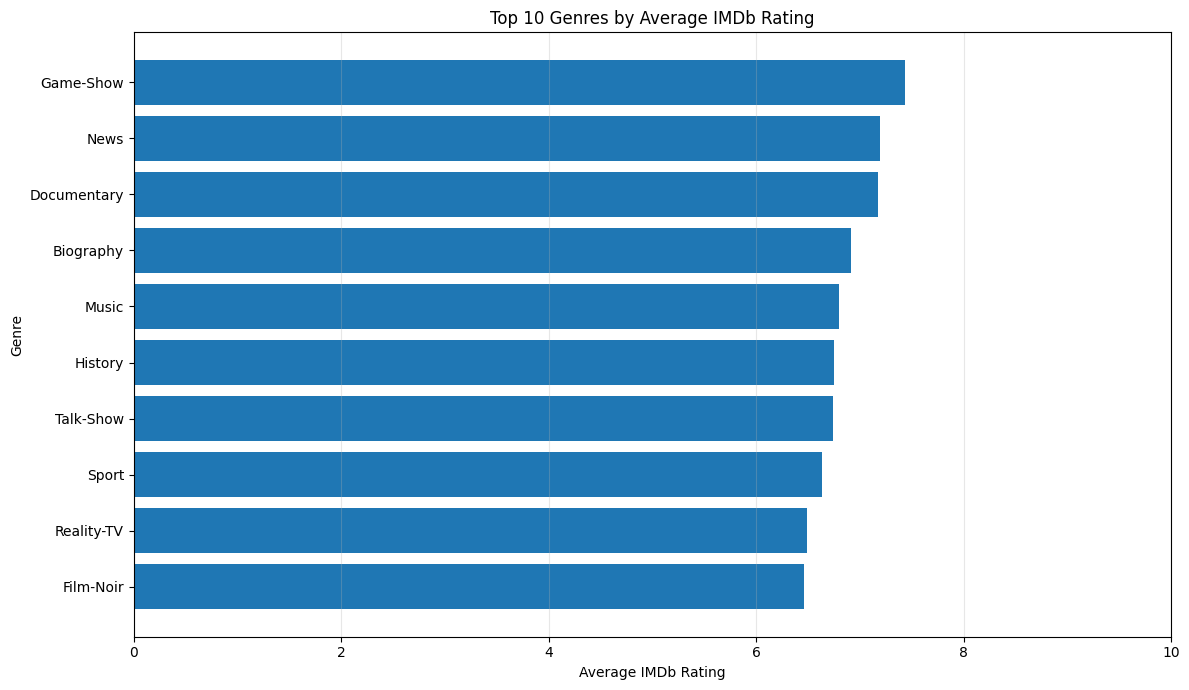

In [32]:
# Top 10 genres by average rating

top_rated_genres = (
    genre_dashboard_summary
    .sort_values("avg_rating", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_rated_genres["genre"][::-1],
    top_rated_genres["avg_rating"][::-1]
)

plt.title("Top 10 Genres by Average IMDb Rating")
plt.xlabel("Average IMDb Rating")
plt.ylabel("Genre")

plt.xlim(0, 10)
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [33]:
# Load movie-level cluster results

movie_clusters = pd.read_csv(
    "../data/processed/movie_clusters.csv"
)

print("Movie cluster data loaded successfully.")
print("Shape:", movie_clusters.shape)

display(movie_clusters.head())

Movie cluster data loaded successfully.
Shape: (307142, 6)


,averageRating,numVotes,runtimeMinutes,year,log_numVotes,cluster
0,6.0,1084.0,70.0,1906,6.989335,2
1,4.8,40.0,90.0,1907,3.713572,2
2,4.9,82.0,120.0,1908,4.418841,2
3,4.2,39.0,45.0,1909,3.688879,2
4,3.2,28.0,58.0,1910,3.367296,2


In [34]:
# Create cluster distribution summary

cluster_dashboard = (
    movie_clusters
    .groupby("cluster")
    .size()
    .reset_index(name="movie_count")
    .sort_values("cluster")
)

print("Cluster distribution:")
display(cluster_dashboard)

Cluster distribution:


,cluster,movie_count
0,0,71281
1,1,50980
2,2,65498
3,3,90638
4,4,28745


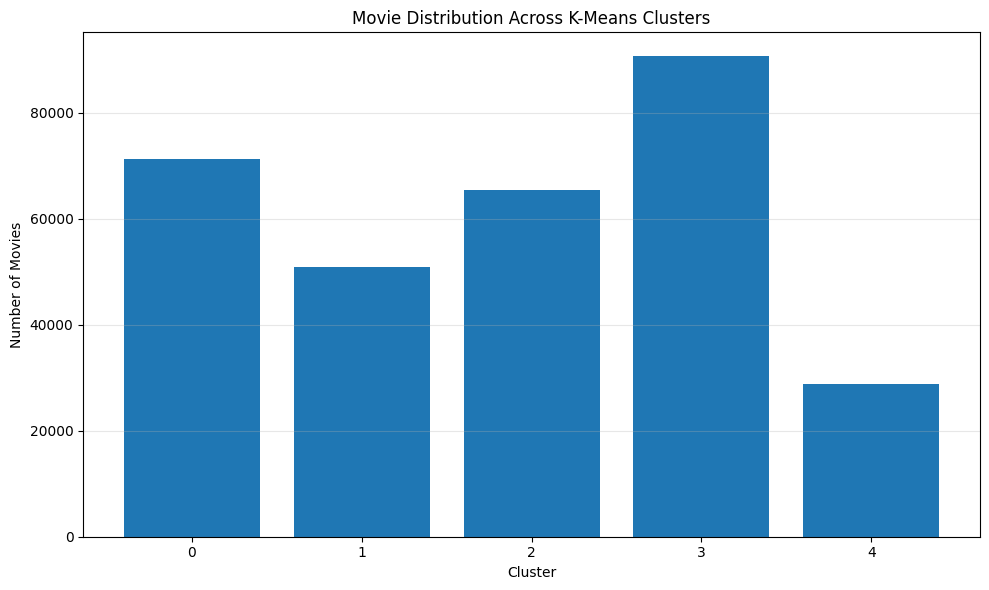

In [35]:
# Visualize movie distribution across K-Means clusters

plt.figure(figsize=(10, 6))

plt.bar(
    cluster_dashboard["cluster"].astype(str),
    cluster_dashboard["movie_count"]
)

plt.title("Movie Distribution Across K-Means Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Movies")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [36]:
# Validate all dashboard-ready datasets

dashboard_files = {
    "KPIs": "../data/processed/dashboard_kpis.csv",
    "Genre Summary": "../data/processed/dashboard_genre_summary.csv",
    "Decade Summary": "../data/processed/dashboard_decade_summary.csv",
    "Genre Trends": "../data/processed/dashboard_genre_trends.csv",
    "Movie Clusters": "../data/processed/movie_clusters.csv"
}

print("===== DASHBOARD DATASET VALIDATION =====")

for name, path in dashboard_files.items():
    temp = pd.read_csv(path)

    print(
        f"{name}: "
        f"{temp.shape[0]:,} rows × "
        f"{temp.shape[1]} columns"
    )

===== DASHBOARD DATASET VALIDATION =====
KPIs: 6 rows × 2 columns
Genre Summary: 27 rows × 4 columns
Decade Summary: 13 rows × 4 columns
Genre Trends: 307 rows × 3 columns
Movie Clusters: 307,142 rows × 6 columns


In [37]:
# Display the main dashboard datasets

print("===== DASHBOARD OVERVIEW =====")

print("\n1. KPI Summary")
display(dashboard_kpis)

print("\n2. Top Genres")
display(genre_dashboard_summary.head(10))

print("\n3. Decade Trends")
display(decade_dashboard_summary.head(10))

print("\n4. Cluster Distribution")
display(cluster_dashboard)

===== DASHBOARD OVERVIEW =====

1. KPI Summary


,metric,value
0,Total Movies,5.696550e+05
1,Average Rating,6.130000e+00
2,Total Votes,1.290659e+09
3,Average Runtime,8.954000e+01
4,Earliest Movie Year,1.900000e+03
5,Latest Movie Year,2.026000e+03



2. Top Genres


,genre,movie_count,avg_rating,avg_votes
8,Drama,240101,6.18,4128.65
7,Documentary,139858,7.17,318.80
5,Comedy,109361,5.88,4651.08
0,Action,49704,5.72,10946.57
20,Romance,49304,6.06,4164.47
6,Crime,38141,5.96,8328.28
24,Thriller,37977,5.57,7513.61
14,Horror,34077,4.96,5110.09
2,Adventure,26762,5.84,16111.44
9,Family,17923,6.14,4252.31



3. Decade Trends


,decade,movie_count,avg_rating,avg_votes
0,1900,106,3.27,46.92
1,1910,2012,5.71,143.64
2,1920,3957,5.83,592.69
3,1930,8990,6.01,816.93
4,1940,8888,6.14,1294.94
5,1950,12855,6.15,1465.19
6,1960,17127,6.04,1494.17
7,1970,22732,5.89,1893.81
8,1980,25128,5.95,3203.09
9,1990,26102,6.02,6630.45



4. Cluster Distribution


,cluster,movie_count
0,0,71281
1,1,50980
2,2,65498
3,3,90638
4,4,28745


In [40]:
# Export clean cluster distribution for frontend

cluster_export = cluster_dashboard[["movie_count"]].copy()

cluster_export.insert(
    0,
    "cluster",
    cluster_export.index
)

cluster_export.reset_index(drop=True, inplace=True)

cluster_export.to_csv(
    "../frontend/public/data/dashboard_cluster_distribution.csv",
    index=False
)

print("Clean cluster distribution CSV exported successfully.")

Clean cluster distribution CSV exported successfully.


# Phase 13: Interactive Visualization & Dashboard Preparation — Conclusion

## Objectives Completed

The dashboard preparation phase successfully transformed the analytical
results from the previous phases into presentation-ready datasets and
visualizations.

### Prepared Components

- Overall movie KPIs
- Genre popularity statistics
- Genre rating comparison
- Decade-wise movie production
- Decade-wise rating trends
- Audience engagement trends
- Genre evolution across decades
- K-Means cluster distribution

## Visualization Coverage

The following visualizations were created:

1. Top genres by number of movies
2. Average IMDb rating across decades
3. Movie production across decades
4. Evolution of top genres
5. Audience engagement across decades
6. Top genres by average IMDb rating
7. Movie distribution across K-Means clusters

## Final Outcome

Phase 13 provides the data and visual foundation required for the final
interactive application.

The prepared CSV datasets can be consumed by a frontend or dashboard
framework to create interactive filters, charts, KPI cards, genre
exploration, decade exploration, and machine-learning cluster analysis.

The project now has a complete analytical pipeline from raw IMDb data
through data preparation, feature engineering, exploratory analysis,
statistical analysis, genre combination analysis, machine learning,
SQL integration, and dashboard preparation.